In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'    # 设置中文显示
plt.rcParams['axes.unicode_minus']=False  # 该语句解决图像中的“-”负号的乱码问题
%matplotlib inline

重复值、缺失值、异常值是**数据清洗**的基本操作。读取数据之后，先对数据进行预览和初步探索，然后进行重复值、缺失值、异常值的操作，包括**“识别”和“处理”**。

|        | 识别                                                         | 处理                                               |
| ------ | :------------------------------------------------------------ | :-------------------------------------------------- |
| 重复值 | df.duplicated()                                              | df.drop_duplicates()                               |
| 缺失值 | df.isna()/df.isnull()，pd.isna()/pd.isnull()<br />df.notna()/df.notnull() | df.dropna()<br />df.fillna()<br />df.interpolate() |
| 异常值 | 箱线图<br />3σ准则                                           |                                                    |

# 1. 重复值

| 序号 | 方法                 | 作用               | 示例                                               | 主要参数                                                     | 其他说明 |
| :--: | :------------------- | :----------------- | :------------------------------------------------- | :----------------------------------------------------------- | :------- |
|  1   | df.duplicated()      | 判断是否是重复值。 | df.duplicated(subset='B', keep='last')             | subset：列名或者列名的组合，如列表。即以某列或某几列为标准，判断整行数据是否重复。默认None，表示该行所有数据与其他行重复才算重复值。<br />keep：first表示重复的第一行不被标记为重复；last表示重复的最后一行不被标记为重复。False表示所有重复的行举杯标记为重复。 |          |
|  2   | df.drop_duplicates() | 删除重复值。       | df.drop_duplicates(inplace=True,ignore_index=True) | subset：同上。<br />keep：同上，是否保留该行。<br />inplace：是否在原始数据上进行修改。<br />ignore_index：是否忽略原始索引，生成新的位置索引。 |          |

## 1.1 重复值识别

In [2]:
df = pd.DataFrame([
    [1, 2, 3],
    [1, 2, 3],
    [1, 2, 4],
    [1, 3, 5],
    [1, 2, 3]
],columns=list('ABC'))
df

,A,B,C
0,1,2,3
1,1,2,3
2,1,2,4
3,1,3,5
4,1,2,3


In [3]:
# 以A和B列为标准判断重复，保留最后一行为不重复
df.duplicated(subset = ['A','B'],keep = 'last')


0     True
1     True
2     True
3    False
4    False
dtype: bool

In [4]:
# 以A和B列为标准判断重复，保留第一行为不重复
df.duplicated(subset = ['A','B'],keep = 'first')

0    False
1     True
2     True
3    False
4     True
dtype: bool

In [5]:
# 以B列为标准判断重复，所有都标记为重复
df.duplicated(subset = 'B',keep = 'first')

0    False
1     True
2     True
3    False
4     True
dtype: bool

In [6]:
# 常使用
df.duplicated().sum()  # 计算重复值的个数

np.int64(2)

## 1.2 重复值删除

In [7]:
df = pd.DataFrame([
    [1, 2, 3],
    [1, 2, 3],
    [1, 2, 4],
    [1, 3, 5],
    [1, 2, 3]
],columns=list('ABC'))
df

,A,B,C
0,1,2,3
1,1,2,3
2,1,2,4
3,1,3,5
4,1,2,3


In [10]:
# 以AB为判断标准，保留最后一行不重复，删除重复值处理之后重置索引
df.drop_duplicates(subset = ['A','B'],keep = 'last',ignore_index = True)

,A,B,C
0,1,3,5
1,1,2,3


In [12]:
# 最常用处理方式
df.drop_duplicates(inplace = True,ignore_index = True)
df

,A,B,C
0,1,2,3
1,1,2,4
2,1,3,5


练习1：读取数据源中上海餐饮数据，命名为df，查看是否存在重复值，并删除重复值。处理完成后将数据存到result文件夹里面命名为上海餐饮数据.csv

In [16]:
# 读取数据，命名为df，预览前5行
df = pd.read_csv(r'数据源/上海餐饮数据.csv',encoding = 'gbk')
df.head(5)

,类别,行政区,点评数,口味,环境,服务,人均消费,城市,Lng,Lat
0,烧烤,浦东新区,176,8.0,8.6,7.9,124,上海市,121.967860,30.884477
1,美食,闵行区,2,6.1,6.5,6.3,0,上海市,121.967781,30.883818
2,粤菜,浦东新区,141,6.7,7.2,6.6,141,上海市,121.933142,30.893224
3,海鲜,浦东新区,76,7.2,7.2,7.3,148,上海市,121.926062,30.899868
4,烧烤,浦东新区,600,7.2,7.6,7.0,143,上海市,121.925877,30.901100


In [17]:
# 查看数据集的基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96398 entries, 0 to 96397
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   类别      96258 non-null  object 
 1   行政区     96255 non-null  object 
 2   点评数     96398 non-null  int64  
 3   口味      96398 non-null  float64
 4   环境      96398 non-null  float64
 5   服务      96398 non-null  float64
 6   人均消费    96398 non-null  int64  
 7   城市      96398 non-null  object 
 8   Lng     96398 non-null  float64
 9   Lat     96398 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 7.4+ MB


In [20]:
# 查看重复值
df.duplicated().sum()  # 计算重复值的个数

np.int64(18714)

In [21]:
# 处理重复值
df.drop_duplicates(inplace = True,ignore_index = True)
df

,类别,行政区,点评数,口味,环境,服务,人均消费,城市,Lng,Lat
0,烧烤,浦东新区,176,8.0,8.6,7.9,124,上海市,121.967860,30.884477
1,美食,闵行区,2,6.1,6.5,6.3,0,上海市,121.967781,30.883818
2,粤菜,浦东新区,141,6.7,7.2,6.6,141,上海市,121.933142,30.893224
3,海鲜,浦东新区,76,7.2,7.2,7.3,148,上海市,121.926062,30.899868
4,烧烤,浦东新区,600,7.2,7.6,7.0,143,上海市,121.925877,30.901100
...,...,...,...,...,...,...,...,...,...,...
77679,本菜,黄浦区,2,7.1,7.1,7.1,0,上海市,109.556522,18.242452
77680,美食,嘉定区,2,7.3,7.4,7.4,0,上海市,107.557465,30.613898
77681,料理,闵行区,43,7.2,7.1,7.0,25,上海市,107.371337,24.510765
77682,甜点,普陀区,0,0.0,0.0,0.0,0,上海市,107.064797,29.831243


In [23]:
# 存储,不写入行索引所在列
df.to_csv(r'result/上海餐饮数据.csv',index= False)

# 2. 缺失值

| 序号 | 方法                                             | 作用                 | 示例                                                         | 主要参数                                                     | 其他说明                                                     |
| :--: | :----------------------------------------------- | :------------------- | :----------------------------------------------------------- | :----------------------------------------------------------- | :----------------------------------------------------------- |
|  1   | df.isna()/df.isnull()<br />pd.isna()/pd.isnull() | 判断是否是缺失值。   | df.isna()<br />                                              |                                                              | Pandas中，缺失值的默认值是NaN（Not a Number）；此外，Python中的None也作为缺失值处理。 |
|  2   | df.notna()/df.notnull()                          | 判断是否不是缺失值   | df.notna()                                                   |                                                              | 非缺失值的识别也可以使用**~符号**与缺失值识别方法或函数的搭配。 |
|  3   | df.dropna()                                      | 删除缺失值。         | df.dropna(how='all')                                         | axis：0（默认）表示删除缺失值所在行；1表示删除缺失值所在列。<br />how：any（默认）表示只要该行存在缺失值，即删除；all表示该行所有值均缺失再删除。<br />thresh：int类型。当该行或该列存在n个或n个以上‘非缺失值’元素时，则不删除该行或该列。<br />subset：以某一列或某几列为标准进行删除。<br />inplace：是否直接在原始数据上进行处理。 | 注意：不是删除缺失值的单元格，而是删除缺失值所在的行或列。<br />subset：必须是组合数据类型，不能直接是列名字符串。 |
|  4   | df.fillna()                                      | 缺失值填充           | df.fillna(1)<br />df.fillna(df.mean().mean())<br />df.fillna(df.mean())<br />df.fillna(method='pad')<br />df.fillna(method='backfill') | value：填充的值。可以是标量、字典、Series、DataFrame均可。<br />method：backfill,bfill, pad, ffill,None；默认是None。pad / ffill：从当前NaN的前面找一个非空的值填充（向前找）；backfill / bfill：从当前NaN的后面找一个非空值进行填充（向后找）。<br />limit：大于0的整数。和method搭配使用，向前找或前后找最大的最大数量。 | **value和method只能同时用一个**。<br />limit必须在method定义时才使用。 |
|  5   | df.interpolate()                                 | 插值法进行缺失值填充 | df.interpolate()                                             | method:  'linear'（默认）                                    | 插值法的计算方式有很多，线性插值法、拉格朗日插值法、牛顿插值法、Hermite插值法、样条插值等。 |

## 2.1 缺失值的识别

In [24]:
df = pd.DataFrame(
    [[1, None, 3], [4, np.nan, np.nan], [7, 8, 9], [np.nan, np.nan, np.nan]],
    columns=list('ABC'))
df

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,NaN
2,7.0,8.0,9.0
3,NaN,NaN,NaN


In [25]:
# 判断缺失值情况
df.isna(),df.isnull()

(       A      B      C
 0  False   True  False
 1  False   True   True
 2  False  False  False
 3   True   True   True,
        A      B      C
 0  False   True  False
 1  False   True   True
 2  False  False  False
 3   True   True   True)

In [26]:
# 按行查看缺失值
df.isna().sum(axis=1)

0    1
1    2
2    0
3    3
dtype: int64

In [27]:
# 按列查看缺失值
df.isna().sum()

A    1
B    3
C    2
dtype: int64

In [30]:
# 以C列为基准，筛选出非空的行
df[df['C'].notna()],df[~df['C'].isna()]

(     A    B    C
 0  1.0  NaN  3.0
 2  7.0  8.0  9.0,
      A    B    C
 0  1.0  NaN  3.0
 2  7.0  8.0  9.0)

In [31]:
# 筛选出不存在空值的行（该行的所有值均为非空）
df[df.notna().all(axis = 1)]

,A,B,C
2,7.0,8.0,9.0


## 2.2 缺失值的删除

df.dropna(axis=0, how='any', thresh=None, subset=None, inplace=False)  
（1）how：any或者all。默认为any，即当前行或列只要存在空值，就删除。  
（2）thresh：int类型。当该行或该列存在n个或n个以上‘非缺失值’元素时，则不删除该行或该列。  
（3）subset：必须是列表类型，不能直接是列名（字符串）。

In [32]:
df = pd.DataFrame(
    [[1, None, 3], [4, np.nan, np.nan], [7, 8, 9], [np.nan, np.nan, np.nan], [13, 14, 15]],
    columns=list('ABC'))
df

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,NaN
2,7.0,8.0,9.0
3,NaN,NaN,NaN
4,13.0,14.0,15.0


In [33]:
# 将只要存在NaN的行进行删除后，剩余的内容（返回新的值）
df.dropna()

,A,B,C
2,7.0,8.0,9.0
4,13.0,14.0,15.0


In [34]:
# 将只要存在NaN的列进行删除
df.dropna(axis = 1)

""
0
1
2
3
4


In [35]:
# 将全部NaN的行进行删除后，剩余的内容（返回新的值）
df.dropna(how = 'all')

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,NaN
2,7.0,8.0,9.0
4,13.0,14.0,15.0


In [36]:
# 存在1个或1个以上非空值的行，则不删除
df.dropna(thresh = 1)

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,NaN
2,7.0,8.0,9.0
4,13.0,14.0,15.0


In [37]:
# 以A列和C列为基准删除缺少的行
df.dropna(subset = ['A','C'])

,A,B,C
0,1.0,NaN,3.0
2,7.0,8.0,9.0
4,13.0,14.0,15.0


## 2.3 缺失值的填充

（1）一般来说，如果缺失的比例比较大，且无法通过其他数据关联关系推理出缺失值，则只能将缺失值删除；而缺失比例较小时，则可以考虑将缺失值替换（填充）为其他值。  
（2）填充缺失值的方法一般有：df.fillna()和df.interpolate()。df.fillna()是基于给定的某个特定值进行填充；df.interpolate()是采用插值法进行填充。

### 2.3.1 一般填充

df.fillna(value=None,method=None,axis=None,inplace=False,limit=None,downcast=None)  
（1）value：填充的值。可以是标量、字典、Series、DataFrame均可。  
（2）method：backfill,bfill, pad, ffill,None；默认是None。**value和method只能同时用一个**。 pad / ffill：从当前NaN的前面找一个非空的值填充（向前找）；backfill / bfill：从当前NaN的后面找一个非空值进行填充（向后找）。  
（3）limit：大于0的整数。和method搭配使用，连续填充的最大数量。

In [38]:
df = pd.DataFrame(
    [[1, None, 3], [4, np.nan, np.nan], [7, 8, 9], [np.nan, np.nan, np.nan], [13, 14, 15]],
    columns=list('ABC'))
df

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,NaN
2,7.0,8.0,9.0
3,NaN,NaN,NaN
4,13.0,14.0,15.0


In [39]:
# 填充固定的值
df.fillna({'A':1,'B':2,'C':3})

,A,B,C
0,1.0,2.0,3.0
1,4.0,2.0,3.0
2,7.0,8.0,9.0
3,1.0,2.0,3.0
4,13.0,14.0,15.0


In [40]:
# 标量填充
df.fillna(1)

,A,B,C
0,1.0,1.0,3.0
1,4.0,1.0,1.0
2,7.0,8.0,9.0
3,1.0,1.0,1.0
4,13.0,14.0,15.0


In [41]:
# 最常见的，填充均值
df.fillna(df.mean())

,A,B,C
0,1.00,11.0,3.0
1,4.00,11.0,9.0
2,7.00,8.0,9.0
3,6.25,11.0,9.0
4,13.00,14.0,15.0


In [42]:
# 每一个NaN均使用df的总的平均值进行填充。
df.fillna(df.mean().mean())

,A,B,C
0,1.00,8.75,3.00
1,4.00,8.75,8.75
2,7.00,8.00,9.00
3,8.75,8.75,8.75
4,13.00,14.00,15.00


In [43]:
# 向前查找填充
df.fillna(method='pad')

C:\Users\leng\AppData\Local\Temp\ipykernel_18180\3415070203.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='pad')


,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,3.0
2,7.0,8.0,9.0
3,7.0,8.0,9.0
4,13.0,14.0,15.0


In [44]:
# 向后查找填充
df.fillna(method='backfill')

C:\Users\leng\AppData\Local\Temp\ipykernel_18180\1996590970.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='backfill')


,A,B,C
0,1.0,8.0,3.0
1,4.0,8.0,9.0
2,7.0,8.0,9.0
3,13.0,14.0,15.0
4,13.0,14.0,15.0


### 2.3.2 插值填充

【思考】x=3时，y=600；x=5时，y=1000；那么x=4时，y等于多少。

（1）插值法是利用已知点近似计算未知点的近似计算方法，即构造一个函数，使其通过所有已知点，然后用求得的函数预测位置点。插值法的计算方式有很多，线性插值法、拉格朗日插值法、牛顿插值法、Hermite插值法、样条插值等。  
（2）pandas中的插值函数是df.interpolate(**method: 'str' = 'linear'**,axis: 'Axis' = 0,limit: 'Optional[int]' = None,inplace: 'bool_t' = False,limit_direction: 'Optional[str]' = None,limit_area: 'Optional[str]' = None,downcast: 'Optional[str]' = None,**kwargs)  
1）method：字符串类型；插值方法。默认是linear，即线性插值法。

In [45]:
df = pd.DataFrame(
    [[1, None, 3], [4, np.nan, np.nan], [7, 8, 9], [np.nan, np.nan, np.nan], [13, 14, 15]],
    columns=list('ABC'))
df

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,NaN
2,7.0,8.0,9.0
3,NaN,NaN,NaN
4,13.0,14.0,15.0


In [46]:
# 线性插值，两点直接直线连接
df.interpolate()

,A,B,C
0,1.0,NaN,3.0
1,4.0,NaN,6.0
2,7.0,8.0,9.0
3,10.0,11.0,12.0
4,13.0,14.0,15.0


In [47]:
df = pd.DataFrame([(0.0, np.nan, -1.0, 1.0),
                   (np.nan, 2.0, np.nan, np.nan),
                   (2.0, 3.0, np.nan, 9.0),
                   (np.nan, 4.0, -4.0, 16.0)],
                   columns=list('ABCD'))
df

,A,B,C,D
0,0.0,NaN,-1.0,1.0
1,NaN,2.0,NaN,NaN
2,2.0,3.0,NaN,9.0
3,NaN,4.0,-4.0,16.0


In [49]:
# 最近邻插值，前后都有临近值默认取后
df.interpolate(method='nearest')

,A,B,C,D
0,0.0,NaN,-1.0,1.0
1,0.0,2.0,-1.0,1.0
2,2.0,3.0,-4.0,9.0
3,NaN,4.0,-4.0,16.0


练习2：读取result中上海餐饮数据，命名为df，查看是否存在缺失值，根据情况处理缺失值。将处理好的数据再次存入result文件夹里面，命名为上海餐饮数据新

缺失值处理决策流程：
├── 缺失比例 > 40% → 删除变量/列
├── 缺失比例 5%-40% → 进入详细分析
│   ├── 分类变量 → 众数/新类别插补
│   ├── 数值变量 → 
│   │   ├── 时间序列 → 时间插值
│   │   ├── 有趋势 → 回归插补
│   │   └── 随机分布 → 均值/中位数
│   └── 多变量相关 → 多重插补
└── 缺失比例 < 5% → 简单删除或插补

In [51]:
# 读取数据，命名为df，预览前5行
df = pd.read_csv(r'result\上海餐饮数据.csv',encoding='utf-8')
df.head()

,类别,行政区,点评数,口味,环境,服务,人均消费,城市,Lng,Lat
0,烧烤,浦东新区,176,8.0,8.6,7.9,124,上海市,121.967860,30.884477
1,美食,闵行区,2,6.1,6.5,6.3,0,上海市,121.967781,30.883818
2,粤菜,浦东新区,141,6.7,7.2,6.6,141,上海市,121.933142,30.893224
3,海鲜,浦东新区,76,7.2,7.2,7.3,148,上海市,121.926062,30.899868
4,烧烤,浦东新区,600,7.2,7.6,7.0,143,上海市,121.925877,30.901100


In [52]:
df.info()  #数据的基本信息

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77684 entries, 0 to 77683
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   类别      77570 non-null  object 
 1   行政区     77568 non-null  object 
 2   点评数     77684 non-null  int64  
 3   口味      77684 non-null  float64
 4   环境      77684 non-null  float64
 5   服务      77684 non-null  float64
 6   人均消费    77684 non-null  int64  
 7   城市      77684 non-null  object 
 8   Lng     77684 non-null  float64
 9   Lat     77684 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 5.9+ MB


In [53]:
# 缺失值识别
df.isna().sum()

类别      114
行政区     116
点评数       0
口味        0
环境        0
服务        0
人均消费      0
城市        0
Lng       0
Lat       0
dtype: int64

In [54]:
# 方法一填充/方法二删除
df.dropna(inplace = True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77568 entries, 0 to 77683
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   类别      77568 non-null  object 
 1   行政区     77568 non-null  object 
 2   点评数     77568 non-null  int64  
 3   口味      77568 non-null  float64
 4   环境      77568 non-null  float64
 5   服务      77568 non-null  float64
 6   人均消费    77568 non-null  int64  
 7   城市      77568 non-null  object 
 8   Lng     77568 non-null  float64
 9   Lat     77568 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 6.5+ MB


In [56]:
# 存储，不写入行索引所在列
df.to_csv(r'result\上海餐饮数据新.csv',encoding='gbk',index=False)

# 3. 异常值

（1）异常值是指数据存在异常，如数学意义错误（如分母为0），违背业务逻辑（如购房需求与预算明显不一致），不同数据（字段）间逻辑不一致（身份证和性别不符），极端值或离群点（Outlier）。  
（2）其他异常值的识别需要依靠业务规律或经验进行识别；极端值或离群点可以从数理统计层面，一般可以使用箱线图或3σ准则进行识别。
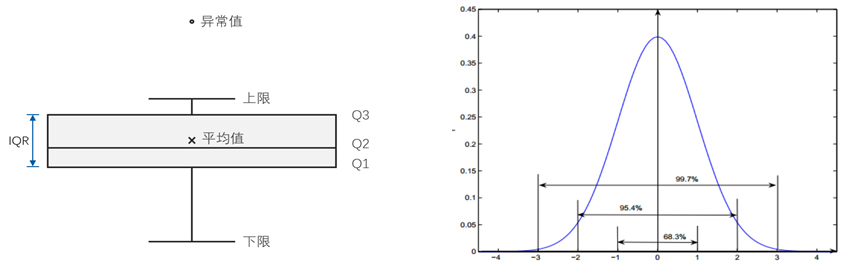

## 3.1 箱线图

箱线图是一种比较简单，直观的离群值的识别方法，其不要求数据服从正态分布。如果数据位于上限或下限以外，则为离群值。  
（1）IQR（四分位距） = Q3 - Q1  
（2）上限：Q3+1.5\*IQR；Excel中，如果理论的上限小于最大值，则真实上限为非离群值中最大的值；如果理论的上限大于最大值，则最大值即为实际的上限。  
（3）下限：Q1-1.5\*IQR；Excel中，如果理论是下限大于最小值，则实际下限为非离群值中最小的值；如果理论的下限小于最小值，则最小值即为真实的下限。

In [57]:
s = pd.Series([
    6, 21, -2, -6, 5, 5, 4, 17, 80, 12, 33, 32, 27, 20, 0, -40, 46, 42, 31, 34
])

In [59]:
# 计算四分位距
q1 = s.quantile(q = 0.25)
q3 = s.quantile(q = 0.75)
iqr = q3 - q1
iqr

np.float64(27.5)

In [60]:
# 计算理论上限和理论下限
ceiling = q3 + 1.5 * iqr
flooring = q1 - 1.5 * iqr
ceiling,flooring

(np.float64(73.5), np.float64(-36.5))

In [61]:
# 判断是否有超出理论上限和理论下限的值
s[(s > ceiling) | (s < flooring)]

8     80
15   -40
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x2a6be26c770>,
 'caps': [<matplotlib.lines.Line2D at 0x2a6be26ca70>,
 'boxes': [<matplotlib.lines.Line2D at 0x2a6be22c410>],
 'medians': [<matplotlib.lines.Line2D at 0x2a6be26d400>],
 'fliers': [<matplotlib.lines.Line2D at 0x2a6be26d4f0>],
 'means': []}

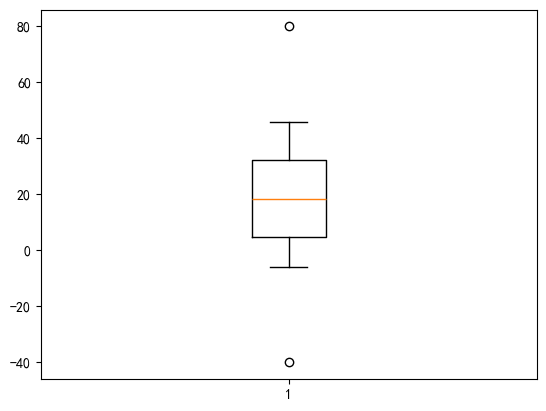

In [62]:
# 可视化
plt.boxplot(s)

练习3：读取数据源中学生信息表，查看年龄列是否存在异常值，用两种方法查看

In [63]:
# 读取数据命名为df，预览前5行
df = pd.read_excel(r'数据源\学生信息表.xlsx')
df.head()

,学号,姓名,性别,年龄,籍贯
0,S001,怠涵,女,70,山东
1,S002,婉清,女,22,河南
2,S003,溪榕,女,25,湖北
3,S004,漠涓,女,23,陕西
4,S005,祈博,女,19,山东


In [64]:
# 方法1
# 计算四分位距
q1 = df['年龄'].quantile(q = 0.25)
q3 = df['年龄'].quantile(q = 0.75)
iqr = q3 - q1
iqr

np.float64(3.25)

In [65]:
# 计算理论上限和理论下限
ceiling = q3 + 1.5 * iqr
floor = q1 - 1.5 * iqr
ceiling,floor

(np.float64(29.125), np.float64(16.125))

In [66]:
# 判断是否有超出理论上限和理论下限的值
df[(df['年龄'] > ceiling) | (df['年龄'] < floor)]

,学号,姓名,性别,年龄,籍贯
0,S001,怠涵,女,70,山东


{'whiskers': [<matplotlib.lines.Line2D at 0x2a6bee289e0>,
 'caps': [<matplotlib.lines.Line2D at 0x2a6bee56480>,
 'boxes': [<matplotlib.lines.Line2D at 0x2a6be3e4200>],
 'medians': [<matplotlib.lines.Line2D at 0x2a6bee568a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2a6bee56bd0>],
 'means': []}

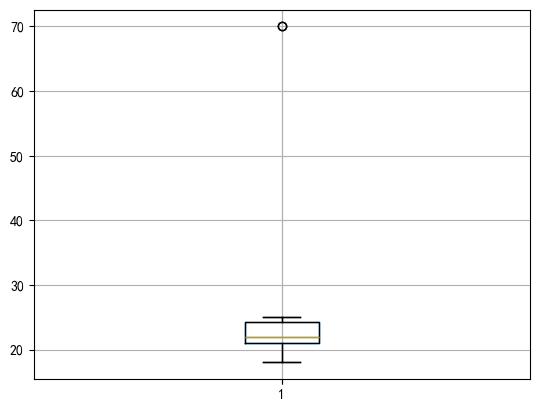

In [67]:
# 方法2可视化
df.boxplot(column = '年龄')
plt.boxplot(df['年龄'])

## 3.2 3σ准则

（1）3σ准则又称拉依达准则，如果一组数据服从正态分布或服从近似正态分布，则数值如果偏离中心（μ）的距离大于3σ，则可将该数值视为离群值。  
（2）p(|x - μ| > 3σ) ≤ 0.003，即数据偏离均值大于3σ的概率小于0.3%，是几乎不可能发生的小概率事件。  
（3）正态性检验：作图法，如直方图、P-P图、Q-Q图；统计检验，K-S检验、W检验。

检查思路  
1：确认数据集是否为正态分布，正态分布的数据才能使用3σ原则。  
2：计算数据的均值和标准差。  
3：检测是否有小于μ-3σ或者μ+3σ的值。

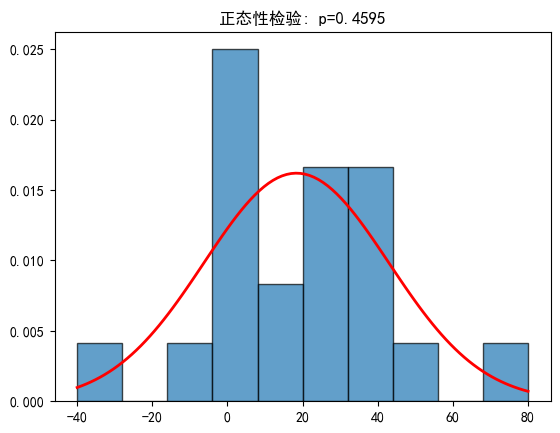

Shapiro-Wilk检验p值: 0.4595
结论: 数据服从正态分布


In [68]:
# W检验与K-S检验一样，原假设是“样本数据来自的分布与正态分布无显著差异”，即p>0.05时，原来假设成立。
# K-S：stats.kstest(s,cdf='norm') W:stats.shapiro(s)
# 样本量较小时（小于50），优先选择W检验；样本量50-5000，酌情使用W检验或K—S检验；样本量大于5000，使用K-S检验。
# 结合直方图检测
import matplotlib.pyplot as plt
from scipy import stats

s = pd.Series([6, 21, -2, -6, 5, 5, 4, 17, 80, 12, 33, 32, 27, 20, 0, -40, 46, 42, 31, 34])
plt.hist(s, bins=10, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(s.min(), s.max(), 100)
plt.plot(x, stats.norm.pdf(x, s.mean(), s.std()), 'r-', lw=2)
plt.title(f'正态性检验: p={stats.shapiro(s)[1]:.4f}') 
plt.show()

# 输出检验结果
print(f"Shapiro-Wilk检验p值: {stats.shapiro(s)[1]:.4f}")
print("结论: 数据服从正态分布" if stats.shapiro(s)[1] > 0.05 else "结论: 数据不服从正态分布")

In [69]:
# 简单检验
from scipy import stats
stats. shapiro(s)

ShapiroResult(statistic=np.float64(0.9555654777634087), pvalue=np.float64(0.4594775168251657))

In [70]:
# 计算μ-3σ和μ+3σ
ceiling = s.mean()+ 3* s.std()
flooring = s.mean()- 3* s.std()
ceiling, flooring

(np.float64(92.2222047293767), np.float64(-55.5222047293767))

In [71]:
# 判断异常值
s[(s>ceiling)|(s<flooring)]

Series([], dtype: int64)

## 3.3异常值处理

①删除含有异常值的记录:直接将含有异常值的记录删除。  
②视为缺失值:将异常值视为缺失值，利用处理缺失值的方法进行处理。  
③平均值修正:用前后两个数据的平均值修正该异常值。  
④不处理:直接对有异常值的数据集进行数据挖掘。  
df.drop()或者df.replace()

# 4. 练习与答案

练习1：读取报名表中数据，统计不同报名状态的数量。

In [73]:
# 读取报名表数据，预览前3行，命名为df
df = pd.read_excel(r'数据源/报名表.xlsx')
df.head(3)

,序号,ID,提交时间,互联网+报名状态
0,1,20218,2022-05-13 22:02:53,已经报名，组长是外系的其他同学
1,2,20108,2022-05-13 22:02:55,已经报名，自己是组长
2,3,20112,2022-05-13 22:03:00,不计划参加此次比赛


In [74]:
# 查看数据集基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   序号        89 non-null     int64 
 1   ID        89 non-null     int64 
 2   提交时间      89 non-null     object
 3   互联网+报名状态  89 non-null     object
dtypes: int64(2), object(2)
memory usage: 2.9+ KB


In [75]:
# 从整体识别重复值
df.duplicated().sum()

np.int64(0)

In [76]:
# 查看ID非重复值个数
df['ID'].nunique()

84

In [77]:
# 以ID列为参照识别重复值个数
df.duplicated(subset = 'ID').sum()

np.int64(5)

In [78]:
# 将ID重复的行筛选出来
df[df.duplicated(subset = 'ID',keep = False)]

,序号,ID,提交时间,互联网+报名状态
3,4,20225,2022-05-13 22:03:07,计划参加，正在报名中，组长是外系的其他同学
19,20,20225,2022-05-13 22:14:05,计划参加，正在报名中，组长是外系的其他同学
33,34,20111,2022-05-14 12:44:46,不计划参加此次比赛
35,36,20111,2022-05-14 12:46:13,不计划参加此次比赛
47,48,20103,2022-05-15 12:07:33,不计划参加此次比赛
58,59,20206,2022-05-15 12:12:21,不计划参加此次比赛
59,60,20103,2022-05-15 12:12:25,不计划参加此次比赛
74,75,20234,2022-05-15 18:25:35,不计划参加此次比赛
75,76,20234,2022-05-15 18:25:53,计划参加，正在报名中，组长是我们系的其他同学
77,78,20206,2022-05-16 09:03:15,不计划参加此次比赛


In [79]:
# 以ID类为参照，保持最后一行不被标记为重复删除重复值，重置索引，并将处理之后的数据赋值给新的变量dfN
dfN = df.drop_duplicates(subset = 'ID',keep = 'last',ignore_index = True)
dfN

,序号,ID,提交时间,互联网+报名状态
0,1,20218,2022-05-13 22:02:53,已经报名，组长是外系的其他同学
1,2,20108,2022-05-13 22:02:55,已经报名，自己是组长
2,3,20112,2022-05-13 22:03:00,不计划参加此次比赛
3,5,20203,2022-05-13 22:03:10,计划参加，正在报名中，计划自己做组长
4,6,20205,2022-05-13 22:04:11,计划参加，正在报名中，组长是我们系的其他同学
...,...,...,...,...
79,85,20220,2022-05-16 09:08:32,不计划参加此次比赛
80,86,20135,2022-05-16 09:09:33,不计划参加此次比赛
81,87,20221,2022-05-16 09:18:55,不计划参加此次比赛
82,88,20207,2022-05-16 09:50:56,计划参加，正在报名中，组长是我们系的其他同学


In [80]:
# 统计不同报名状态的数量，且将数据变成DataFrame类型，并赋值给一个新的变量dfS
dfS = dfN['互联网+报名状态'].value_counts().to_frame()
dfS

,count
互联网+报名状态,
不计划参加此次比赛,47
计划参加，正在报名中，组长是我们系的其他同学,24
计划参加，正在报名中，计划自己做组长,5
计划参加，正在报名中，组长是外系的其他同学,4
已经报名，组长是外系的其他同学,3
已经报名，自己是组长,1


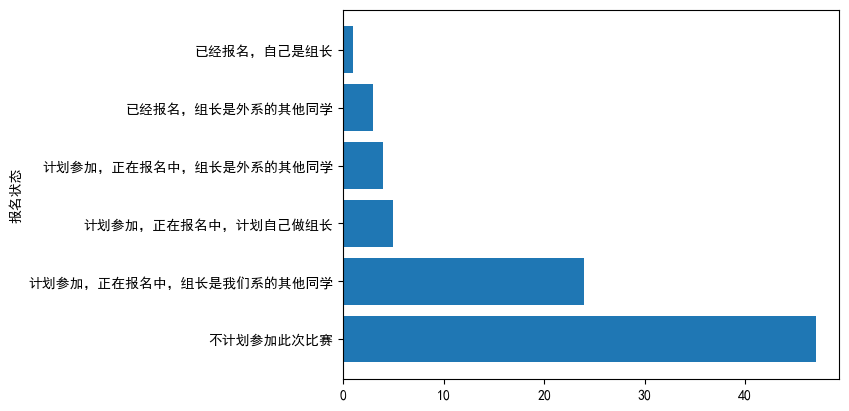

In [81]:
# 可视化报名状态，绘制水平条形图
plt.barh(y= dfS.index,width=dfS['count'])
plt.ylabel('报名状态')
plt.show()

练习2：  
（1）读取表2《Python语言程序设计》课程成绩.xlsx中1班成绩，用Excel表中第2行作为表头，第1列（序号）作为索引。  
（2）对数据进行必要的预览及初步的探索；将学号列转换成字符串类型。  
（3）查看并统计数据是否存在重复数据，如果存在，则直接在原始数据上删除重复数据（保留重复数据中的第一条），并更新索引。  
（4）查看并统计数据中每个字段是否存在缺失值，并筛选所有存在缺失值记录（不含备注列）。  
（5）将所有的缺失值填充为0分，并创建一个新的DataFrame对象（如dfN）（不含备注列）。  
（6）按照箱线图逻辑，查看总成绩列是否存在离群值，如果存在离群值，则删除离群值所在行，并创建一个新的DataFrame对象（如dfN2），并重置索引为新的位置索引。  
（7）绘制总成绩的箱线图和直方图。

In [82]:
# 按要求读取数据，命名为df，预览前2行
df = pd.read_excel(r'数据源/表2《Python语言程序设计》课程成绩.xlsx', 
                   sheet_name=0,header=1, index_col=0)
df.head(2)

,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
序号,,,,,,,,,,,,,,
1,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
2,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN


In [84]:
# 查看数据集基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 1 to 45
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   学号      45 non-null     int64  
 1   姓名      45 non-null     object 
 2   考勤      44 non-null     float64
 3   课堂表现    44 non-null     float64
 4   作业1     44 non-null     float64
 5   作业2     44 non-null     float64
 6   作业3     44 non-null     float64
 7   作业4     44 non-null     float64
 8   作业5     44 non-null     float64
 9   作业6     44 non-null     float64
 10  半期考试    44 non-null     float64
 11  期末考试    43 non-null     float64
 12  总成绩     43 non-null     float64
 13  备注      2 non-null      object 
dtypes: float64(11), int64(1), object(2)
memory usage: 5.3+ KB


In [85]:
# 将学号列转换成字符串类型
df['学号'] = df['学号'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 1 to 45
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   学号      45 non-null     object 
 1   姓名      45 non-null     object 
 2   考勤      44 non-null     float64
 3   课堂表现    44 non-null     float64
 4   作业1     44 non-null     float64
 5   作业2     44 non-null     float64
 6   作业3     44 non-null     float64
 7   作业4     44 non-null     float64
 8   作业5     44 non-null     float64
 9   作业6     44 non-null     float64
 10  半期考试    44 non-null     float64
 11  期末考试    43 non-null     float64
 12  总成绩     43 non-null     float64
 13  备注      2 non-null      object 
dtypes: float64(11), object(3)
memory usage: 5.3+ KB


In [86]:
# 查看并统计数据是否存在重复数据
df.duplicated().sum()

np.int64(2)

In [87]:
# 将重复的数据取出
df[df.duplicated(keep = False)]

,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
序号,,,,,,,,,,,,,,
10,60060250110,屈磊,100.0,100.0,100.0,59.0,23.0,96.0,87.0,100.0,71.0,83.0,83.55,NaN
23,60060250123,张凤秋,100.0,90.0,100.0,82.0,25.0,86.0,79.0,100.0,53.0,68.0,75.10,NaN
44,60060250110,屈磊,100.0,100.0,100.0,59.0,23.0,96.0,87.0,100.0,71.0,83.0,83.55,NaN
45,60060250123,张凤秋,100.0,90.0,100.0,82.0,25.0,86.0,79.0,100.0,53.0,68.0,75.10,NaN


In [89]:
# 处理重复值，在原始数据上删除重复数据（保留重复数据中的第一条），并更新索引
df.drop_duplicates(inplace = True,ignore_index = True)

In [90]:
# 按列查看缺失值
df.isna().sum()

学号       0
姓名       0
考勤       1
课堂表现     1
作业1      1
作业2      1
作业3      1
作业4      1
作业5      1
作业6      1
半期考试     1
期末考试     2
总成绩      2
备注      41
dtype: int64

In [91]:
# 按行查看缺失值
df.isna().sum(axis=1)

0      1
1      1
2      1
3      1
4      1
5      1
6      1
7      1
8      1
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     1
17     1
18     1
19     1
20     1
21     1
22     1
23     1
24     1
25     1
26     1
27     1
28     1
29     1
30     1
31     1
32     1
33     1
34     1
35     2
36     1
37     1
38     1
39    11
40     1
41     1
42     1
dtype: int64

In [92]:
# 筛选出除备注列缺失的行
df[df.isna().sum(axis= 1)> 1]

,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
35,60060250136,明相慧,0.0,70.0,50.0,60.0,40.0,0.0,0.0,0.0,97.0,NaN,NaN,取消期末考试资格
39,60060250140,宋林蓉,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,修学


In [93]:
# 除备注列缺失值填充为0分
dfN = df. iloc[:,:- 1]. fillna(0)
dfN

,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩
0,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15
1,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20
2,60060250103,王伟杰,100.0,70.0,100.0,74.0,35.0,87.0,86.0,100.0,54.0,79.0,78.10
3,60060250104,肖鹏,100.0,100.0,100.0,85.0,60.0,77.0,72.0,100.0,69.0,71.0,80.00
4,60060250105,朱柯宁,100.0,90.0,100.0,71.0,30.0,97.0,91.0,100.0,84.0,76.0,82.25
5,60060250106,周聪,100.0,80.0,100.0,53.0,37.0,86.0,88.0,100.0,32.0,66.0,70.80
6,60060250107,刘多,100.0,100.0,100.0,52.0,100.0,93.0,87.0,100.0,88.0,82.0,88.20
7,60060250108,田昶,100.0,80.0,100.0,42.0,63.0,97.0,87.0,100.0,61.0,74.0,78.15
8,60060250109,刘佳坤,100.0,100.0,100.0,85.0,60.0,93.0,83.0,100.0,61.0,71.0,80.55
9,60060250110,屈磊,100.0,100.0,100.0,59.0,23.0,96.0,87.0,100.0,71.0,83.0,83.55


In [94]:
# 异常值判断
q1 = dfN['总成绩'].quantile(q= 0.25)
q3 = dfN['总成绩'].quantile(q= 0.75)
iqr = q3- q1
ceiling = q3+ 1.5* iqr
flooring = q1- 1.5* iqr
dfN[(dfN['总成绩']> ceiling)| (dfN['总成绩']< flooring)]

,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩
28,60060250129,张博,100.0,90.0,100.0,74.0,53.0,100.0,83.0,100.0,61.0,70.0,-50.0
35,60060250136,明相慧,0.0,70.0,50.0,60.0,40.0,0.0,0.0,0.0,97.0,0.0,0.0
39,60060250140,宋林蓉,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
# 删除异常值所在行，并重置索引，并命名为dfN2
dfN2 = dfN.drop(index= [28,35,39]). reset_index(drop= True )
dfN2

,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩
0,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15
1,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20
2,60060250103,王伟杰,100.0,70.0,100.0,74.0,35.0,87.0,86.0,100.0,54.0,79.0,78.10
3,60060250104,肖鹏,100.0,100.0,100.0,85.0,60.0,77.0,72.0,100.0,69.0,71.0,80.00
4,60060250105,朱柯宁,100.0,90.0,100.0,71.0,30.0,97.0,91.0,100.0,84.0,76.0,82.25
5,60060250106,周聪,100.0,80.0,100.0,53.0,37.0,86.0,88.0,100.0,32.0,66.0,70.80
6,60060250107,刘多,100.0,100.0,100.0,52.0,100.0,93.0,87.0,100.0,88.0,82.0,88.20
7,60060250108,田昶,100.0,80.0,100.0,42.0,63.0,97.0,87.0,100.0,61.0,74.0,78.15
8,60060250109,刘佳坤,100.0,100.0,100.0,85.0,60.0,93.0,83.0,100.0,61.0,71.0,80.55
9,60060250110,屈磊,100.0,100.0,100.0,59.0,23.0,96.0,87.0,100.0,71.0,83.0,83.55


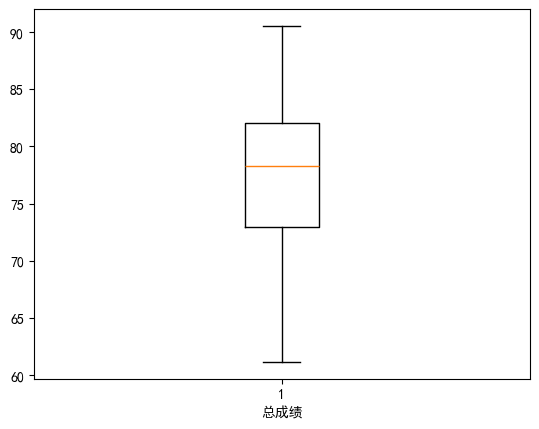

In [98]:
# 绘制总成绩的箱线图
plt. boxplot(dfN2['总成绩'])
plt. xlabel('总成绩')
plt. show()

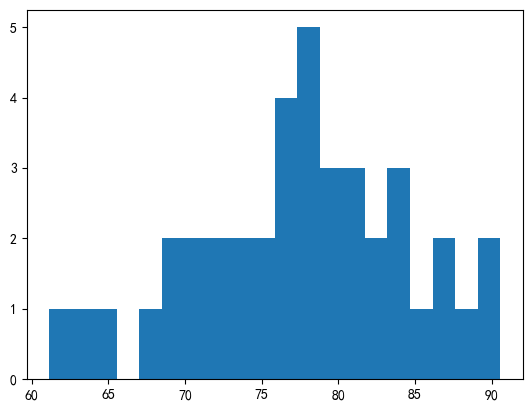

In [99]:
# 绘制直方图
plt. hist(dfN2['总成绩'],bins= 20)
plt. show()

# 5. 总结

（1）重复值：df.duplicated()、df.drop_duplicates()  
（2）缺失值：df.isna()/df.isnull()/pd.isna()/pd.isnull()、df.notna()/df.notnull()、df.dropna()、df.fillna()、df.interpolate()  
（3）异常值：箱线图、3σ准则